In [1]:
import scanpy as sc
from itertools import combinations
from scipy.spatial.distance import cdist
import sys 
from geopandas import read_parquet, points_from_xy
import os
folder_path = os.path.abspath('/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_code')
if folder_path not in sys.path:
        sys.path.append(folder_path)
from analysis_utils import *


In [14]:
def load_my_data(cell_meta_f, tx_meta_f, adata_f, mistic_path, custome_t_idx = 0, tag="mistic"):
    cell_meta = pd.read_csv(cell_meta_f)
    tx_meta = read_parquet(tx_meta_f).set_index('transcript_id')
    pre = sc.read_h5ad(adata_f)
    tx_remove = pd.read_parquet(mistic_path + f'/{tag}_tx_to_remove.parquet')
    tx_reassignment = pd.read_parquet(mistic_path + f'/{tag}_tx_to_reassign.parquet')
    #reassignment = pd.read_csv(mistic_path + '/reassignment.csv', index_col=1)
    #resovi_post = sc.read_h5ad(mistic_path + '/supervised_resolvi.h5ad')
    mistic_t = pd.read_csv(mistic_path + f'/{tag}_criteria_df.csv')
    tx_meta.rename(
        columns = {
            'x_location':'global_x',
            'y_location':'global_y',
            'feature_name':'gene',
            },
        inplace=True
    )
    tx_meta = tx_meta[['global_x','global_y', 'gene','cell_id']]
    cell_meta.rename(
        columns = {
            'x_centroid':'center_x',
            'y_centroid':'center_y',
            },
        inplace=True
    )
    cell_meta = cell_meta[['center_x','center_y', 'leiden']]
    tx_meta.index = ['tx_' + str(i) for i in range(len(tx_meta))]
    tx_meta = tx_meta[tx_meta.cell_id.isin(pre.obs_names)]
    # load resolVI
    #resovi_post.X = resovi_post.layers['generated_expression']
    #resovi_post.layers['counts'] = resovi_post.X.copy()
    # Generate misc corrected counts
    post = pre.copy()
    tx_info = tx_meta.copy()
    tx_info = tx_info.drop(tx_remove.molecule_id.values)
    tx_info.loc[tx_reassignment.molecule_id, 'cell_id'] = tx_reassignment.to_cell_id.values
    corrected_counts = tx_info.groupby(['cell_id','gene']).count().iloc[:,0].reset_index()
    corrected_counts = corrected_counts.pivot(
        index='cell_id', columns='gene', values=corrected_counts.columns[2]).fillna(0)
    cm_cells = [x for x in corrected_counts.index if x in post.obs_names]
    post = post[cm_cells]
    post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
    post.layers['counts'] = post.X

    # correction to match resolVI level of TX removal
    reassign_t = mistic_t.iloc[custome_t_idx,0]
    remove_t = mistic_t.iloc[custome_t_idx,4]
    print('Custom cutoffs for reassignment: {:.2f}, removal: {:.2f}'.format(reassign_t, remove_t))
    #reassign_tx = reassignment[reassignment.reassign_probs>=reassign_t].copy()
    #remove_tx = reassignment.loc[
    #    (reassignment.reassign_probs<reassign_t) & 
    #    (reassignment.reassign_probs>=remove_t)
    #    ].index
    #tx_info = tx_meta.drop(remove_tx).copy()
    #tx_info.loc[reassign_tx.index,'cell_id'] = reassign_tx.neighbor_cell_id.values
    corrected_counts2 = tx_info.groupby(['cell_id','gene']).count().iloc[:,0].reset_index()
    corrected_counts2 = corrected_counts2.pivot(
        index='cell_id', columns='gene', values=corrected_counts2.columns[2]).fillna(0)
    #post2 = pre[corrected_counts2.index].copy()
    #post2.X = corrected_counts2.loc[post2.obs_names, post2.var_names].values
    #post2.layers['counts'] = post2.X
    return pre, post , tx_meta, tx_reassignment, tx_remove #, reassignment



In [18]:
cell_meta_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/processed_cell_metadata_reindexed.csv"
tx_meta_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/process_tx_meta_filtered_filtered.parquet"
adata_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/processed_adata.h5ad"

In [19]:
mistic_path_1 = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/batchsize/outs/fig3/patch_01"
mistic_path_2 = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/batchsize/outs/fig3/patch_05"
mistic_path_3 = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/batchsize/outs/fig3/patch_10"
mistic_path_4 = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/batchsize/outs/fig3/patch_15"
mistic_path_5 = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/batchsize/outs/fig3/patch_20"
mistic_paths = [mistic_path_1, mistic_path_2, mistic_path_3,mistic_path_4, mistic_path_5]

In [20]:
tx = ["01", "05", "10", "15", "20"]

In [23]:
adatas = []

In [25]:
for index, mistic in enumerate(mistic_paths):
    pre, post , tx_meta, tx_reassignment, tx_remove = load_my_data(cell_meta_f, tx_meta_f, adata_f, mistic, custome_t_idx = 0, tag="mistic")
    del tx_meta
    del tx_reassignment
    del tx_remove
    gc.collect()
    adatas.append(post)

/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_1495431/4231015519.py:42: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/scipy/sparse/_index.py:207: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/tmp/ipykernel_1495431/4231015519.py:43: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  post.layers['counts'] = post.X


Custom cutoffs for reassignment: 0.20, removal: 0.20


/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_1495431/4231015519.py:42: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/scipy/sparse/_index.py:207: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/tmp/ipykernel_1495431/4231015519.py:43: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  post.layers['counts'] = post.X


Custom cutoffs for reassignment: 0.20, removal: 0.20


/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_1495431/4231015519.py:42: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/scipy/sparse/_index.py:207: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/tmp/ipykernel_1495431/4231015519.py:43: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  post.layers['counts'] = post.X


Custom cutoffs for reassignment: 0.20, removal: 0.20


/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_1495431/4231015519.py:42: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/scipy/sparse/_index.py:207: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/tmp/ipykernel_1495431/4231015519.py:43: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  post.layers['counts'] = post.X


Custom cutoffs for reassignment: 0.20, removal: 0.20


/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_1495431/4231015519.py:42: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/scipy/sparse/_index.py:207: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/tmp/ipykernel_1495431/4231015519.py:43: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  post.layers['counts'] = post.X


Custom cutoffs for reassignment: 0.20, removal: 0.20


In [26]:
print(len(adatas))

5


In [27]:
cts = ['T_cell', 'Endothelial_cell','Macrophage', 'Tumor_cell', 'Fibroblast']
me_genes = {
    'Endothelial_cell': ['VWF','EGFL7','CLEC14A','ECSCR','CD34'],
    'B_cell': ['CD79A','MS4A1', 'BANK1', 'MZB1', 'CD19'],
    'Fibroblast': ['FBLN1','ACTA2','PCOLCE','THY1','FBN1'],
    'Macrophage': ['AIF1', 'CD68', 'FCGR3A', 'MS4A6A', 'MRC1'],
    'T_cell': ['CCL5','TRAC','CD3D','CD3E','GZMA'],
    'Tumor_cell': ['KRT7', 'SFTA2', 'AGR3', 'EPCAM', 'GPRC5A'],
}
ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'}

In [28]:
me_genes_filtered = {}
for cell_type, genes in me_genes.items():
    valid = [g for g in genes if g in pre.var_names]
    missing = set(genes) - set(valid)
    if missing:
        print(f"[{cell_type}] missing from dataset: {missing}")
    if valid:
        me_genes_filtered[cell_type] = valid

print(f"\nUsing {sum(len(v) for v in me_genes_filtered.values())} / "
      f"{sum(len(v) for v in me_genes.values())} marker genes total\n")

[Endothelial_cell] missing from dataset: {'VWF'}
[Fibroblast] missing from dataset: {'FBLN1', 'FBN1'}
[Macrophage] missing from dataset: {'MRC1'}
[T_cell] missing from dataset: {'TRAC'}
[Tumor_cell] missing from dataset: {'AGR3', 'SFTA2', 'KRT7'}

Using 22 / 30 marker genes total



In [29]:
gc.collect()

26

In [30]:
adata_raw = sc.read_10x_h5("/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/cell_feature_matrix.h5")  # or .read_mtx / read_csv

# Align barcodes (in case of subsetting)
common_obs = pre.obs_names.intersection(adata_raw.obs_names)
pre.layers["counts"] = adata_raw[common_obs, pre.var_names].X.copy()
pre.X = adata_raw[common_obs, pre.var_names].X.copy()

In [31]:
adatas.insert(0,pre)

In [32]:
print(len(adatas))

6


In [33]:
resolvi_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_luad_results/resolvi.h5ad"
adata_resolvi = sc.read_h5ad(resolvi_f)

In [34]:
adata_resolvi.X = adata_resolvi.layers['generated_expression']
adata_resolvi.layers['counts'] = adata_resolvi.X.copy()

In [35]:
resovi_post_round = adata_resolvi.copy()
tmp = resovi_post_round.layers['generated_expression']
tmp[tmp<0.1] = 0
adata_resolvi.layers['counts'] = tmp

In [38]:
adatas.append(adata_resolvi)

In [36]:
import seaborn as sns
import pandas as pd
def my_me_exp_plot(
        cts, 
        me_genes, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = ['Pre','MisC','ResolVI','MisC_overcorrection']):
    res = []
    for i, _adata in enumerate(adatas):
        _adata = _adata.copy()
        _adata.X = _adata.layers['counts']
        sc.pp.normalize_total(_adata)
        sc.pp.log1p(_adata)
        df_exp = _adata.to_df()
        # df_exp = (df_exp>df_exp.quantile(0.05)) + 0
        if ct_col not in _adata.obs.columns:
            ct_col = 'leiden'
        ctype = _adata.obs[ct_col].astype(str)
        ctype = ctype.astype(str).replace(ct_rename_dict)
        cosine_dist = pd.DataFrame(index=cts, columns=cts)
        idx = []
        cosine_dist = []
        for g,c in combinations(cts,2):
            c_genes = me_genes[c]
            g_genes = me_genes[g]
            _df = df_exp[ctype.isin(cts)]
            base_exp = _df[c_genes].sum(axis=1)
            me_exp = _df[g_genes].sum(axis=1)
            cs = 1 - cdist(base_exp.values.reshape(1,-1), me_exp.values.reshape(1,-1), metric='cosine')[0,0]
            idx.append('-'.join(sorted([g,c])))
            cosine_dist.append(cs)
        tmp = pd.DataFrame(cosine_dist, index=idx, columns = ['CS']).sort_index()
        tmp['Preprocessing'] = labels[i]
        res.append(tmp)
    res = pd.concat(res)
    res = res.reset_index()
    res.columns = ['ME_group', 'CS', 'Preprocessing']
    sns.barplot(data = res, x = 'ME_group', y= 'CS', hue = 'Preprocessing')
    plt.xticks(rotation=90)
    # plt.savefig(output_path + '/ME_exp_comparison.pdf', bbox_inches='tight')

In [48]:
import seaborn as sns
import pandas as pd
def my_me_exp_plot_correct_colors(
        cts, 
        me_genes, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = ['Pre','MisC','ResolVI','MisC_overcorrection']):
    res = []
    custom_palette = {
    'Pre': '#4C72B0',
    'MisTIC_1%': "#1fb482",
    'MisTIC_5%': "#ce38ec",
    'MisTIC_10%': '#DD8452',
    'MisTIC_15%': "#ff6edf",
    'MisTIC_20%': '#8c564b',
    'ResolVI': '#C44E52'
    }
    for i, _adata in enumerate(adatas):
        _adata = _adata.copy()
        _adata.X = _adata.layers['counts']
        sc.pp.normalize_total(_adata)
        sc.pp.log1p(_adata)
        df_exp = _adata.to_df()
        # df_exp = (df_exp>df_exp.quantile(0.05)) + 0
        if ct_col not in _adata.obs.columns:
            ct_col = 'leiden'
        ctype = _adata.obs[ct_col].astype(str)
        ctype = ctype.astype(str).replace(ct_rename_dict)
        cosine_dist = pd.DataFrame(index=cts, columns=cts)
        idx = []
        cosine_dist = []
        for g,c in combinations(cts,2):
            c_genes = me_genes[c]
            g_genes = me_genes[g]
            _df = df_exp[ctype.isin(cts)]
            base_exp = _df[c_genes].sum(axis=1)
            me_exp = _df[g_genes].sum(axis=1)
            cs = 1 - cdist(base_exp.values.reshape(1,-1), me_exp.values.reshape(1,-1), metric='cosine')[0,0]
            idx.append('-'.join(sorted([g,c])))
            cosine_dist.append(cs)
        tmp = pd.DataFrame(cosine_dist, index=idx, columns = ['CS']).sort_index()
        tmp['Preprocessing'] = labels[i]
        res.append(tmp)
    res = pd.concat(res)
    res = res.reset_index()
    res.columns = ['ME_group', 'CS', 'Preprocessing']
    sns.barplot(data=res, x='ME_group', y='CS', hue='Preprocessing', palette=custom_palette)
    plt.xticks(rotation=90)
    # plt.savefig(output_path + '/ME_exp_comparison.pdf', bbox_inches='tight')

In [39]:
print(len(adatas))

7


In [42]:
print(adatas)

[AnnData object with n_obs × n_vars = 156230 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'leiden', 'leiden_sub', 'score_Endothelial_cell', 'score_B_cell', 'score_Fibroblast', 'score_Macrophage', 'score_T_cell', 'score_Tumor', 'leiden_rescored'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'leiden', 'leiden_colors', 'leiden_rescored_colors', 'leiden_sub', 'leiden_sub_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances', AnnData object with n_obs × n_vars = 156230 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'leiden', 'leiden_sub', 'score_Endothel

In [43]:
labels=['Pre','MisTIC_1%', 'MisTIC_5%', 'MisTIC_10%', 'MisTIC_15%', 'MisTIC_20%', "ResolVI"]

In [44]:
print(len(labels))

7


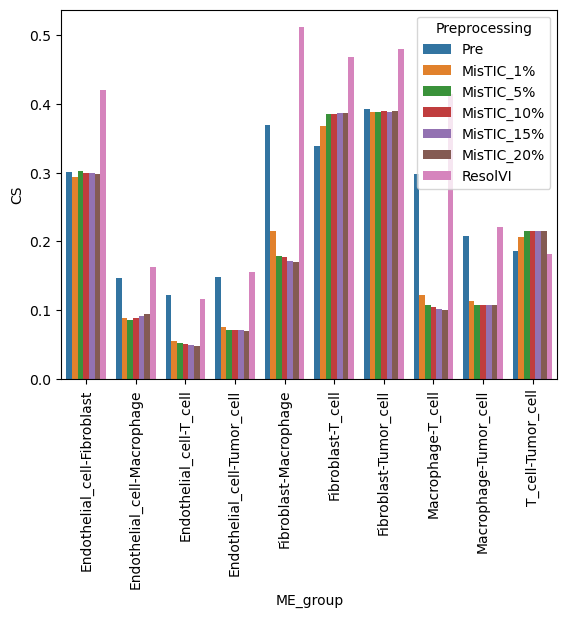

In [49]:
my_me_exp_plot(
        cts, 
        me_genes_filtered, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = labels)

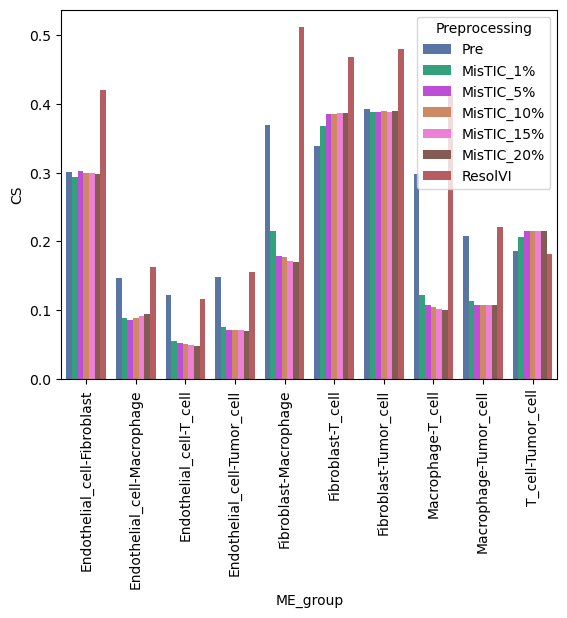

In [50]:
my_me_exp_plot_correct_colors(
        cts, 
        me_genes_filtered, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = labels)